In [238]:
import pandas as pd
import numpy as np

seed = 123
rng = np.random.default_rng(seed)

In [239]:
def sim_vasicek_path(r0, mu, kappa, sigma, dt, T, R, rng):
    n_steps = int(T / dt) + 1

    r = np.zeros((R, n_steps), dtype=float)
    r[:, 0] = r0

    exp_kdt = np.exp(-kappa * dt)
    var = sigma**2 / (2 * kappa) * (1 - exp_kdt**2)
    std = np.sqrt(var)

    for t in range(1, n_steps):
        z = rng.normal(0, 1.0, size=R)
        r[:, t] = exp_kdt * r[:, t - 1] + mu * (1 - exp_kdt) + std * z
    return r

In [240]:
def zcb_bond_price(r_paths, dt):
    integral_r = np.sum(r_paths[:, :-1], axis=1) * dt
    discount = np.exp(-integral_r)
    price = np.mean(discount)
    se = np.std(discount, ddof=1) / np.sqrt(r_paths.shape[0])
    return price, se



In [241]:
def zcb_closed_form(r0, mu, kappa, sigma, T):
    B = (np.exp(-kappa * T) - 1.0) / kappa  
    A = (B + T) * (sigma**2 / (2.0 * kappa**2) - mu) - (sigma**2 * B**2) / (4.0 * kappa)
    return float(np.exp(A + B * r0))

In [242]:
zcb_price = zcb_closed_form(r0=0.05, mu=0.05, kappa=0.8, sigma=0.02, T=1.0)
print('zcb closed-form price:', zcb_price)

zcb closed-form price: 0.9512657315656362


In [243]:
r0 = 0.05
mu = r0
kappa = 0.8
sigma = 0.02
T = 1

deltas = [0.1, 0.01, 0.001]
Rs = [10, 100, 1000]
lmb = 0.0

table = pd.DataFrame(index=[f"1/{int(1/d)}" for d in deltas], columns=[str(R) for R in Rs], dtype=float)

for d in deltas:
    for R in Rs:
        rng = np.random.default_rng(123 + int(1/d)*1000 + R)
        r_paths = sim_vasicek_path(r0, mu, kappa, sigma, d, T, R, rng)
        price, se = zcb_bond_price(r_paths, d)
        table.loc[f"1/{int(1/d)}", str(R)] = price

table_fmt = table.copy()
table_fmt.columns.name = "R"
table_fmt.index.name = "delta"

print(table_fmt.round(4))

R           10     100    1000
delta                         
1/10    0.9499  0.9501  0.9514
1/100   0.9540  0.9500  0.9510
1/1000  0.9517  0.9499  0.9511


In [244]:
def bond_EU_call_price(r0, mu, kappa, sigma, T0, T1, K, R, dt, seed = 123):
    rng = np.random.default_rng(seed)
    r_paths = sim_vasicek_path(r0, mu, kappa, sigma, dt, T1, R, rng)
    
    idx_T0 = int(T0 / dt)
    idx_T1 = int(T1 / dt)

    integral_0_T0 = np.sum(r_paths[:, :idx_T0], axis=1) * dt
    D_0_T0 = np.exp(-integral_0_T0)

    integral_T0_T1_ = np.sum(r_paths[:, idx_T0:idx_T1], axis=1) * dt
    P_T0_T1 = np.exp(-integral_T0_T1_)
    
    payoffs = np.maximum(P_T0_T1 - K, 0)

    discounted_payoffs = D_0_T0 * payoffs
    price = np.mean(discounted_payoffs)
    se = discounted_payoffs.std(ddof=1) / np.sqrt(R)
    return price, se, P_T0_T1
    

In [245]:
price, se, _ = bond_EU_call_price(
    r0=0.05, mu=0.05, kappa=0.8, sigma=0.02,
    T0=0.5, T1=1.0, K=0.95,
    R=20000, dt=0.001, seed=123
)
print(price, se)


0.024698463903544344 4.062054571990735e-05


Example price is 0.0062 (SE ≈ 8.8494e-04)


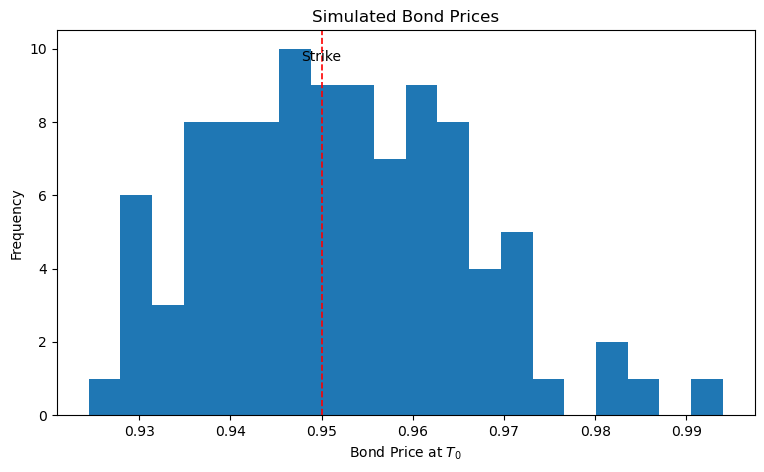

In [246]:
import matplotlib.pyplot as plt


price, se, P_T0_T1 = bond_EU_call_price(
    r0=0.05, mu=0.05, kappa=0.8, sigma=0.02,
    T0=1.0, T1=2.0, K=0.95,   
    R=100, dt=1/1000, seed=123
)

print(f"Example price is {price:.4f} (SE ≈ {se:.4e})")

plt.figure(figsize=(9,5))
plt.hist(P_T0_T1, bins=20, histtype="bar", linewidth=1.5)  
plt.axvline(0.95, linewidth=1.2, color="red", linestyle="--")                            
plt.title("Simulated Bond Prices")
plt.xlabel(r"Bond Price at $T_0$")
plt.ylabel("Frequency")
plt.text(0.95, plt.ylim()[1]*0.95, "Strike", ha="center", va="top")
plt.show()